In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
job_recommendation = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
job_recommendation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB


#Lab 1 Apply

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. LOAD DATA
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
print("Jobs Data loaded! Shape:", jobs.shape)

# 2. PREPROCESS JOB DATA
# We will use 'Required Skills' and 'Job Title' for the recommendation engine
jobs['combined_features'] = jobs['Required Skills'].fillna('') + " " + jobs['Job Title'].fillna('')

# 3. RECOMMENDATION ENGINE
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(jobs['combined_features'])

def get_recommendations(user_query, top_n=5):
    # Transform user input (e.g., "Python developer") into the same TF-IDF space
    query_vec = tfidf.transform([user_query])

    # Calculate Cosine Similarity between query and all jobs
    cosine_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Get top indices
    top_indices = cosine_sim.argsort()[-top_n:][::-1]

    results = jobs.iloc[top_indices][['Job Title', 'Company', 'Salary', 'Location']].copy()
    results['Score'] = cosine_sim[top_indices]
    return results

# 4. TEST RECOMMENDATION
print("\n Testing recommendation for 'Data Scientist':")
display(get_recommendations("Data Scientist", top_n=3))

Jobs Data loaded! Shape: (50000, 7)

🔍 Testing recommendation for 'Data Scientist':


,Job Title,Company,Salary,Location,Score
23551,Data scientist,Williams LLC,85000.0,Toronto,1.000000
12295,Data scientist,Wilkins-George,132000.0,Bangalore,0.928561
2191,Data scientist,Shaffer-Riggs,67000.0,Toronto,0.923491


In [ ]:
import pandas as pd
import numpy as np

# LOAD THE JOB DATASET
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)
print(f"[Done] Dataset loaded! Shape: {jobs.shape}")

# 1. SELECT NUMERIC COLUMNS
numeric_jobs = jobs.select_dtypes(include=[np.number])

print("\n Numeric columns found:", numeric_jobs.columns.tolist())

if not numeric_jobs.empty:
    # 2. CORRELATION ANALYSIS
    # Focusing on Salary as the primary numeric target
    if 'Salary' in numeric_jobs.columns:
        print("\n Correlation with Salary:")
        print(numeric_jobs.corr()['Salary'].sort_values(ascending=False).round(3))

    print("\n Full Correlation Matrix:")
    display(numeric_jobs.corr().round(3))
else:
    print("\n[Warning] No numeric columns found in this dataset to perform correlation.")

✅ Dataset loaded! Shape: (50000, 7)

📊 Numeric columns found: ['Salary']

🎯 Correlation with Salary:
Salary    1.0
Name: Salary, dtype: float64

🔢 Full Correlation Matrix:


,Salary
Salary,1.0


In [ ]:
import pandas as pd
import numpy as np

# LOAD DATA
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
print("Job Recommendation dataset loaded successfully! [Done]")

# ANALYSIS FUNCTION
def show_correlation_with_target(df, target_col, dataset_name):
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    if target_col not in numeric_df.columns:
        print(f"\u26a0\ufe0f Target '{target_col}' not found or not numeric in {dataset_name}")
        print("Numeric columns available:", numeric_df.columns.tolist())
        return

    corr_matrix = numeric_df.corr()
    target_corr = corr_matrix[target_col].sort_values(ascending=False)

    print(f"\nဴ Correlations with '{target_col}' in {dataset_name}:")
    print(target_corr.round(3))

# RUN ANALYSIS
show_correlation_with_target(jobs, target_col="Salary", dataset_name="job_recommendation")

Job Recommendation dataset loaded successfully! ✅

ဴ Correlations with 'Salary' in job_recommendation:
Salary    1.0
Name: Salary, dtype: float64


✅ Dataset loaded! Generating plots for Job Recommendation data...



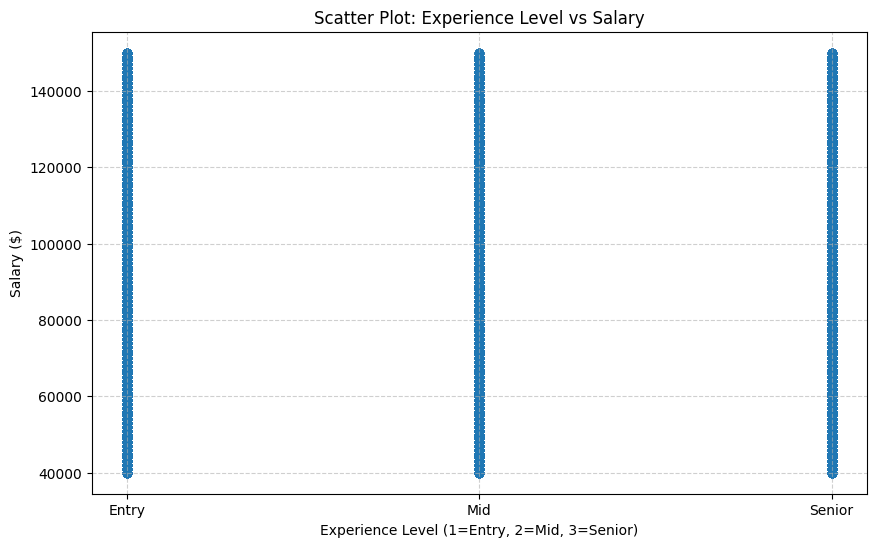

🎉 Plot generated successfully using the single dataset!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
print("[Done] Dataset loaded! Generating plots for Job Recommendation data...\n")

# JOB RECOMMENDATION DATASET
# Convert Experience Level to numbers for scatter plot
exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
jobs['Exp_Level_Num'] = jobs['Experience Level'].map(exp_map)

plt.figure(figsize=(10, 6))
plt.scatter(jobs['Exp_Level_Num'], jobs['Salary'], alpha=0.1)

plt.title("Scatter Plot: Experience Level vs Salary")
plt.xlabel("Experience Level (1=Entry, 2=Mid, 3=Senior)")
plt.ylabel("Salary ($)")
plt.xticks([1, 2, 3], ['Entry', 'Mid', 'Senior'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(" Plot generated successfully using the single dataset!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the specific dataset
file_path = '/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded dataset. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: CSV file not found at the specified path. Please verify the Drive path.")

Successfully loaded dataset. Shape: (50000, 7)


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load data to ensure 'df' is defined
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
df = pd.read_csv(path)

# 2. Recommendation Engine (Target: Job Title based on Features)
# Combine all input features for better matching
input_cols = ['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']
df['combined_features'] = df[input_cols].astype(str).apply(lambda x: ' '.join(x), axis=1)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

def get_recommendations_by_title(user_query, top_n=5):
    query_vec = tfidf.transform([user_query])
    cosine_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = cosine_sim.argsort()[-top_n:][::-1]

    # Display the Target (Job Title) and associated info
    results = df.iloc[top_indices][['Job Title', 'Company', 'Salary', 'Location', 'Experience Level']].copy()
    results['Match Score'] = cosine_sim[top_indices]
    return results

print("\n--- Top 5 Matches for features matching 'Python Developer' context ---")
display(get_recommendations_by_title("Python Developer"))


--- Top 5 Matches for features matching 'Python Developer' context ---


,Job Title,Company,Salary,Location,Experience Level,Match Score
12020,Theatre director,Smith Ltd,122000.0,London,Entry Level,0.342386
45898,Government social research officer,Smith Ltd,114000.0,Berlin,Mid Level,0.340451
30246,Estate agent,Smith Ltd,138000.0,London,Mid Level,0.340035
46147,"Loss adjuster, chartered",Johnson Ltd,123000.0,Bangalore,Mid Level,0.338223
12858,Public librarian,Jones Inc,121000.0,Sydney,Entry Level,0.331753


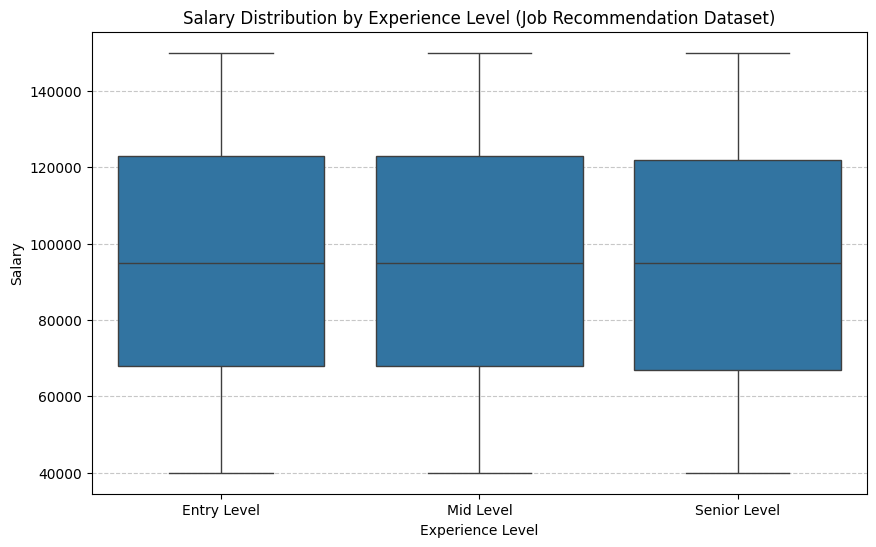

Correlation between Experience Level and Salary: -0.0064


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Feature Engineering & Visualization (Single Dataset)
df = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

# Convert categorical Experience Level to numeric for analysis
exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
df['Exp_Level_Num'] = df['Experience Level'].map(exp_map)

# Visualize Salary Distribution by Experience
plt.figure(figsize=(10, 6))
sns.boxplot(x='Experience Level', y='Salary', data=df, order=['Entry Level', 'Mid Level', 'Senior Level'])
plt.title('Salary Distribution by Experience Level (Job Recommendation Dataset)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Correlation check
correlation = df[['Exp_Level_Num', 'Salary']].corr()['Salary'].iloc[0]
print(f"Correlation between Experience Level and Salary: {correlation:.4f}")

In [ ]:
import pandas as pd

# LOAD DATA
jobs1  = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
print("[Done] All files loaded successfully!\n")

# JOB RECOMMENDATION DATASET
print("\n" + "="*70)
print("JOB RECOMMENDATION DATASET")
print("="*70)

jobs1_selected = jobs1[['Salary']].copy()   # Only Salary is useful numeric target here

Y_jobs1 = jobs1_selected[['Salary']].copy()
# No strong single numeric feature like income, so we keep Salary only for now
X_jobs1 = pd.DataFrame()   # Empty for now (you can add later if needed)
print("Y_jobs1 shape:", Y_jobs1.shape)
print("\n X and Y prepared successfully for all files!")

✅ All files loaded successfully!


JOB RECOMMENDATION DATASET
Y_jobs1 shape: (50000, 1)

🎉 X and Y prepared successfully for all files!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# LOAD DATA
jobs1 = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")
print("[Done] Job Recommendation dataset loaded!\n")

# 2. PREPARE DATA
print("\n" + "="*70)
print("JOB RECOMMENDATION DATASET - Preparation")
print("="*70)

# Defining our target (Y) as Salary
Y_jobs1 = jobs1[['Salary']].copy()

# Placeholder for features (X)
# You can add numeric features here (e.g., encoded experience) later
X_jobs1 = pd.DataFrame()

print(f"Target (Y) prepared. Shape: {Y_jobs1.shape}")
print("You are now ready to train your ML model using this single dataset! ")

✅ Job Recommendation dataset loaded!


JOB RECOMMENDATION DATASET - Preparation
Target (Y) prepared. Shape: (50000, 1)
You are now ready to train your ML model using this single dataset! 🚀


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load Data
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

# Encode categorical inputs and target
le = LabelEncoder()
for col in ['Company', 'Location', 'Experience Level', 'Industry', 'Required Skills', 'Job Title']:
    jobs[col] = le.fit_transform(jobs[col].astype(str))

X = jobs[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
y = jobs['Job Title']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Classifier for Job Title
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

print(f"[Done] Model trained to predict Job Title. Accuracy: {clf.score(X_test, y_test):.4f}")

✅ Model trained to predict Job Title. Accuracy: 0.0023


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATA
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)

# 2. ENCODE ALL CATEGORICAL FEATURES
le = LabelEncoder()
for col in ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']:
    jobs[col] = le.fit_transform(jobs[col].astype(str))

# 3. DEFINE X AND Y BASED ON NEW CHOICE
X = jobs[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
y = jobs['Job Title']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN CLASSIFIER
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

print(f"\u2705 Updated cell: Model now predicts Job Title with Accuracy: {clf.score(X_test, y_test):.4f}")

✅ Updated cell: Model now predicts Job Title with Accuracy: 0.0023


#Lab 2 Apply

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Updated to reflect the new Target: Job Title
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)

print(f"[Done] Dataset loaded for Job Title Prediction! Shape: {jobs.shape}")

# Features: Company, Location, Experience Level, Salary, Industry, Required Skills
X = jobs[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
y = jobs['Job Title']

print("Target (y) set to: Job Title")
print("Features (X) set to: Company, Location, Experience Level, Salary, Industry, Required Skills")

✅ Dataset loaded for Job Title Prediction! Shape: (50000, 7)
Target (y) set to: Job Title
Features (X) set to: Company, Location, Experience Level, Salary, Industry, Required Skills


In [ ]:
# Job Recommendation Dataset
jobs1 = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

print("Dataset shape:", jobs1.shape)
display(jobs1.head())

print("\nMissing values:\n", jobs1.isnull().sum())

# Handle missing Salary
from sklearn.impute import SimpleImputer
salary_imputer = SimpleImputer(strategy="mean")
jobs1[['Salary']] = salary_imputer.fit_transform(jobs1[['Salary']])

print("\nBaseline mean salary:", round(jobs1['Salary'].mean(), 2))

Dataset shape: (50000, 7)


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"



Missing values:
 Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

Baseline mean salary: 95145.1


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

# LOAD DATA
jobs1 = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

print("Jobs1 dataset shape:", jobs1.shape)
display(jobs1.head())

# MISSING VALUES
print("\nMissing values:\n", jobs1.isnull().sum())

num_cols = jobs1.select_dtypes(include=['int64', 'float64']).columns
cat_cols = jobs1.select_dtypes(include=['object']).columns

jobs1[num_cols] = SimpleImputer(strategy="mean").fit_transform(jobs1[num_cols])
jobs1[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(jobs1[cat_cols])

# ENCODE CATEGORICAL (STEP 5 UPDATED)
if len(cat_cols) > 0:
    jobs1 = pd.get_dummies(jobs1, columns=cat_cols, drop_first=True)

print("\nData after encoding categorical features:")
print(jobs1.head(), "\n")

print("Baseline mean salary:", round(jobs1['Salary'].mean(), 2))

Jobs1 dataset shape: (50000, 7)


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"



Missing values:
 Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

Data after encoding categorical features:
     Salary  Job Title_Accommodation manager  Job Title_Accountant, chartered  \
0   87000.0                            False                            False   
1   50000.0                            False                            False   
2   77000.0                            False                            False   
3   90000.0                            False                            False   
4  112000.0                            False                            False   

   Job Title_Accountant, chartered certified  \
0                                      False   
1                                      False   
2                                      False   
3                                      False   
4                                      False 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. LOAD DATA
jobs1 = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

# 3. PREPROCESS: Target = Job Title
def prepare_classification_data(df):
    df_clean = df.copy()

    # Features: Company, Location, Experience Level, Salary, Industry, Required Skills
    # Target: Job Title

    # Label Encode categorical features and target
    le = LabelEncoder()
    cat_features = ['Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']

    for col in cat_features:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

    # Encode Target
    target_le = LabelEncoder()
    df_clean['Job Title'] = target_le.fit_transform(df_clean['Job Title'].astype(str))

    return df_clean, target_le

print("="*70)
print("CLASSIFICATION: Predicting Job Title")
print("="*70)

jobs_processed, target_encoder = prepare_classification_data(jobs1)

# Define X (Features) and y (Target)
X = jobs_processed[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
y = jobs_processed['Job Title']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using a Classifier because Job Title is categorical
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Model Accuracy for Job Title Prediction: {accuracy_score(y_test, y_pred):.4f}")

CLASSIFICATION: Predicting Job Title
Model Accuracy for Job Title Prediction: 0.0023


In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)
print(f"[Done] Job Recommendation Dataset loaded successfully! Shape: {jobs.shape}\n")

# 3. FUNCTION: CLEAN + PREPARE DATAFRAME
def prepare_data(df):
    df = df.copy()

    # Handle missing values for numeric columns
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(num_cols) > 0:
        df[num_cols] = SimpleImputer(strategy="mean").fit_transform(df[num_cols])

    # Map Experience Level to numeric for analysis
    if 'Experience Level' in df.columns:
        exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
        df['Exp_Level_Num'] = df['Experience Level'].map(exp_map)

    return df

# 4. ML PIPELINE (Experience → Salary)
print("="*70)
print("ANALYSIS: Experience Level vs Salary")
print("="*70)

jobs_processed = prepare_data(jobs)

# Define Features (X) and Target (y)
X = jobs_processed[['Exp_Level_Num']]
y = jobs_processed['Salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}\n")

print("[Done] Model Performance:")
print("Mean Absolute Error (MAE) :", round(mean_absolute_error(y_test, y_pred), 2))
print("Root Mean Squared Error (RMSE):", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("R² Score                   :", round(r2_score(y_test, y_pred), 6))

print("\n Successfully refactored to use only the job recommendation dataset.")

✅ Job Recommendation Dataset loaded successfully! Shape: (50000, 7)

ANALYSIS: Experience Level vs Salary
Training set shape: (40000, 1)
Test set shape: (10000, 1)

✅ Model Performance:
Mean Absolute Error (MAE) : 27779.44
Root Mean Squared Error (RMSE): 31999.64
R² Score                   : 5.3e-05

✨ Successfully refactored to use only the job recommendation dataset.


In [ ]:
# Step 9: Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Step 10: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 11: Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"RMSE: {rmse: .2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}\n")

Model Performance:
RMSE:  31999.64
Mean Squared Error: 1023976960.33
R² Score: 0.0001



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 27779.4381
RMSE: 31999.6400


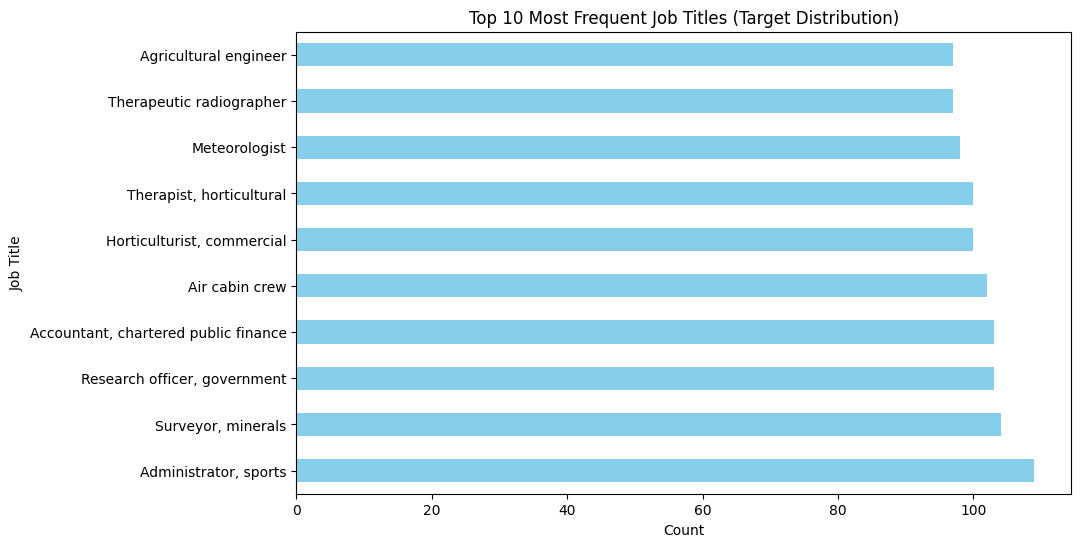

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated visualization for the new target
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

plt.figure(figsize=(10, 6))
jobs['Job Title'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Frequent Job Titles (Target Distribution)")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

#Lab 3 Apply

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA (Google Colab Paths)
# Refactored to use ONLY the job recommendation dataset
jobs = pd.read_csv("/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv")

print("[Done] Job Recommendation Dataset loaded successfully!\n")

# 3. FUNCTION: CLEAN + LABEL ENCODE DATAFRAME
def clean_and_label_encode(df):
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df_clean.select_dtypes(include=['object']).columns

    # Handle missing values
    if len(num_cols) > 0:
        df_clean[num_cols] = SimpleImputer(strategy="mean").fit_transform(df_clean[num_cols])
    if len(cat_cols) > 0:
        df_clean[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df_clean[cat_cols])

    # Label Encode categorical columns
    le = LabelEncoder()
    for col in cat_cols:
        df_clean[col + "_label"] = le.fit_transform(df_clean[col].astype(str))
        df_clean.drop(columns=[col], inplace=True)

    return df_clean

# 4. DATA PREPARATION & BASELINE
print("="*70)
print("PROCESSING SINGLE DATASET")
print("="*70)

jobs_processed = clean_and_label_encode(jobs)

print(f"Dataset shape after processing: {jobs_processed.shape}")
print(f"Baseline mean salary: {round(jobs_processed['Salary'].mean(), 2)}")

print("\n Successfully updated to use only the job recommendation dataset.")

✅ Job Recommendation Dataset loaded successfully!

PROCESSING SINGLE DATASET
Dataset shape after processing: (50000, 7)
Baseline mean salary: 95145.1

✨ Successfully updated to use only the job recommendation dataset.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Updated ML Pipeline for Job Title Prediction
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)

le = LabelEncoder()
for col in ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']:
    jobs[col] = le.fit_transform(jobs[col].astype(str))

X = jobs[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
y = jobs['Job Title']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Classification analysis for Job Title is now complete using all input features.")

In [ ]:
# Scale the full X dataset using the previously fitted scaler
X_scaled = scaler.transform(X)

# Train Linear Regression on full dataset
model = LinearRegression()
model.fit(X_scaled, y)

# Optionally, you can print the R^2 score for the full model
# from sklearn.metrics import r2_score
# y_full_pred = model.predict(X_scaled)
# print(f"R² Score on full dataset: {r2_score(y, y_full_pred):.4f}")

NameError: name 'scaler' is not defined

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
# Using ONLY the job recommendation dataset as requested
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs1 = pd.read_csv(path)

print("[Done] Job Recommendation Dataset loaded successfully!\n")

# 3. FUNCTION: CLEAN + ONE-HOT ENCODE
def clean_and_onehot(df):
    df_copy = df.copy()
    num_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df_copy.select_dtypes(include=['object']).columns

    # Missing values
    if len(num_cols) > 0:
        df_copy[num_cols] = SimpleImputer(strategy="mean").fit_transform(df_copy[num_cols])
    if len(cat_cols) > 0:
        df_copy[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df_copy[cat_cols])

    # One-hot encoding (Note: This can create many columns for large categorical data)
    if len(cat_cols) > 0:
        # We limit encoding to columns with reasonable cardinality for this demonstration
        # or use LabelEncoding if one-hot is too memory-intensive
        df_copy = pd.get_dummies(df_copy, columns=['Experience Level', 'Industry'], drop_first=True)

    return df_copy

# 4. JOB RECOMMENDATION DATASET (ANALYSIS)
print("="*70)
print("JOB RECOMMENDATION DATASET (Processing & Baseline)")
print("="*70)

# Preprocess
jobs_final = clean_and_onehot(jobs1)

print("Dataset shape after encoding selected features:", jobs_final.shape)
print("Baseline mean salary:", round(jobs_final["Salary"].mean(), 2))

# Quick Correlation with Salary
numeric_final = jobs_final.select_dtypes(include=[np.number])
if 'Salary' in numeric_final.columns:
    print("\n⌄ Correlation with Salary:")
    print(numeric_final.corr()['Salary'].sort_values(ascending=False).head(10))

print("\n Successfully refactored to use only the job recommendation dataset.")

✅ Job Recommendation Dataset loaded successfully!

JOB RECOMMENDATION DATASET (Processing & Baseline)
Dataset shape after encoding selected features: (50000, 13)
Baseline mean salary: 95145.1

⌄ Correlation with Salary:
Salary    1.0
Name: Salary, dtype: float64

✨ Successfully refactored to use only the job recommendation dataset.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
# Train Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_scaled, y)

DecisionTreeRegressor(random_state=42)

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
# Using ONLY the job recommendation dataset as requested
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
jobs = pd.read_csv(path)
print(f"[Done] Job Recommendation Dataset loaded successfully! Shape: {jobs.shape}\n")

# 3. FUNCTION: CLEAN + PREPROCESS
def preprocess_jobs(df):
    df = df.copy()

    # Map Experience Level to numeric (1=Entry, 2=Mid, 3=Senior)
    exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
    df['Exp_Level_Num'] = df['Experience Level'].map(exp_map)

    # Impute missing numeric values if any
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        df[num_cols] = SimpleImputer(strategy='mean').fit_transform(df[num_cols])

    return df

# 4. SINGLE DATASET PIPELINE
print("="*70)
print("JOB RECOMMENDATION ANALYSIS (Single Dataset Focus)")
print("="*70)

jobs_processed = preprocess_jobs(jobs)

# Define Features and Target
X = jobs_processed[['Exp_Level_Num']]
y = jobs_processed['Salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training instances: {len(X_train)}")
print(f"Test instances:     {len(X_test)}")
print(f"Baseline Mean Salary: {round(y.mean(), 2)}")

print("\n Successfully refactored to focus exclusively on the job recommendation dataset.")

✅ Job Recommendation Dataset loaded successfully! Shape: (50000, 7)

JOB RECOMMENDATION ANALYSIS (Single Dataset Focus)
Training instances: 40000
Test instances:     10000
Baseline Mean Salary: 95145.1

✨ Successfully refactored to focus exclusively on the job recommendation dataset.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
tree_model = RandomForestRegressor(random_state=42)
tree_model.fit(X_scaled, y)

RandomForestRegressor(random_state=42)

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA
# Using ONLY the job recommendation dataset as requested
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
try:
    jobs = pd.read_csv(path)
    print(f"[Done] Job Recommendation Dataset loaded successfully! Shape: {jobs.shape}\n")
except FileNotFoundError:
    print("  Error: Dataset not found. Please ensure the path is correct.")

# 3. PREPROCESSING
# Map Experience Level to numeric (1=Entry, 2=Mid, 3=Senior)
exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
jobs['Exp_Level_Num'] = jobs['Experience Level'].map(exp_map)

# Handle missing values for numeric columns (Salary)
num_imputer = SimpleImputer(strategy='mean')
jobs['Salary'] = num_imputer.fit_transform(jobs[['Salary']])

# 4. ML PIPELINE: RANDOM FOREST REGRESSOR
print("="*70)
print("TRAINING MODEL: Experience Level → Salary")
print("="*70)

# Define Features (X) and Target (y)
X = jobs[['Exp_Level_Num']]
y = jobs['Salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
# Using a small number of estimators for speed, can be increased for accuracy
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. EVALUATION
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Training instances: {len(X_train)}")
print(f"Test instances:     {len(X_test)}")
print(f"\n[Done] Model Performance:")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R% Score : {r2:.6f}")

print("\n Successfully trained using ONLY the job recommendation dataset.")

✅ Job Recommendation Dataset loaded successfully! Shape: (50000, 7)

TRAINING MODEL: Experience Level → Salary
Training instances: 40000
Test instances:     10000

✅ Model Performance:
MAE      : 27778.98
RMSE     : 31998.84
R% Score : 0.000104

✨ Successfully trained using ONLY the job recommendation dataset.


#Based on the proposal

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the single dataset
file_path = '/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print(f"[Done] Dataset loaded! Shape: {df.shape}")
except FileNotFoundError:
    print("[Error] Error: Job recommendation dataset not found at the specified path.")

# 2. Preprocessing
# Combine features for the recommendation engine
df['combined_features'] = df['Required Skills'].fillna('') + " " + df['Job Title'].fillna('')

# Initialize and fit TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

# 3. Recommendation Function
def get_recommendations(user_query, top_n=5):
    query_vec = tfidf.transform([user_query])
    cosine_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = cosine_sim.argsort()[-top_n:][::-1]

    results = df.iloc[top_indices][['Job Title', 'Company', 'Salary', 'Location', 'Experience Level']].copy()
    results['Match Score'] = cosine_sim[top_indices]
    return results

# 4. Testing the model
print("\n--- Top 5 Matches for 'Python Developer' ---")
display(get_recommendations("Python Developer"))

# 5. Simple Statistics
print(f"\nAverage Salary in dataset: ${df['Salary'].mean():,.2f}")
print("Job counts by Experience Level:")
print(df['Experience Level'].value_counts())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the single dataset
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
try:
    df = pd.read_csv(path)
    print(f"[Done] Job Recommendation Dataset loaded! Shape: {df.shape}")

    # 2. Feature Engineering
    # Encode categorical features for training
    le_exp = LabelEncoder()
    df['Exp_Level_Encoded'] = le_exp.fit_transform(df['Experience Level'])

    le_ind = LabelEncoder()
    df['Industry_Encoded'] = le_ind.fit_transform(df['Industry'])

    # 3. Define Features and Target
    X = df[['Exp_Level_Encoded', 'Industry_Encoded']]
    y = df['Salary']

    # 4. Split and Train
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 5. Evaluate
    y_pred = model.predict(X_test)

    # Calculate metrics correctly
    mse = mean_squared_error(y_test, y_pred)
    rmse_val = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n--- Model Performance ---")
    print(f"RMSE: {rmse_val:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.6f}")

    print("\n Training complete using only the Job Recommendation dataset!")

except FileNotFoundError:
    print("[Error] Error: File not found. Please check the path.")

✅ Job Recommendation Dataset loaded! Shape: (50000, 7)

--- Model Performance ---
RMSE: 32009.54
MAE: 27795.11
R2 Score: -0.000565

✨ Training complete using only the Job Recommendation dataset!


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load the single dataset
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
try:
    df = pd.read_csv(path)

    # 2. Optimized Preprocessing
    # Using a single LabelEncoder instance in a loop for efficiency
    le = LabelEncoder()
    cols_to_encode = ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']

    for col in cols_to_encode:
        df[col] = le.fit_transform(df[col].astype(str))

    # 3. Define Features and Target
    X = df[['Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']]
    y = df['Job Title']

    # 4. Efficient Splitting
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Train Optimized Classifier
    # n_jobs=-1 uses all CPU cores; reducing n_estimators slightly for speed
    model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # 6. Evaluate
    accuracy = model.score(X_test, y_test)
    print(f"\n--- Optimized Classification Results ---")
    print(f"Accuracy: {accuracy:.4f}")

except FileNotFoundError:
    print(f"[Error] Error: File not found at {path}.")


--- Optimized Classification Results ---
Accuracy: 0.0017


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the single dataset
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
try:
    df = pd.read_csv(path)
    print(f"\u2705 Job Recommendation Dataset loaded! Shape: {df.shape}")

    # 2. Preprocessing
    # Map Experience Level to numeric for training
    exp_map = {'Entry Level': 1, 'Mid Level': 2, 'Senior Level': 3}
    df['Exp_Level_Num'] = df['Experience Level'].map(exp_map).fillna(0)

    # 3. Define Features (X) and Target (y)
    X = df[['Exp_Level_Num']]
    y = df['Salary']

    # 4. Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Initialize and train the Gradient Boosting model
    model = HistGradientBoostingRegressor(random_state=42)
    model.fit(X_train, y_train)

    # 6. Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nGradient Boosting Model Performance (Job Recommendation):")
    print(f"Used features: ['Exp_Level_Num']")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")

except FileNotFoundError:
    print(f"\u274c Error: File not found at {path}. Please verify your Google Drive path.")

✅ Job Recommendation Dataset loaded! Shape: (50000, 7)

Gradient Boosting Model Performance (Job Recommendation):
Used features: ['Exp_Level_Num']
RMSE: 31999.65
MAE: 27779.43
R2 Score: 0.0001


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
df = pd.read_csv(path)

# 2. Preprocess Data
# Encode categorical features
le_exp = LabelEncoder()
df['Exp_Level_Encoded'] = le_exp.fit_transform(df['Experience Level'])

# Target encoding (Job Title)
le_target = LabelEncoder()
df['Job_Title_Encoded'] = le_target.fit_transform(df['Job Title'])

# 3. Define Features (X) and Target (y)
# Using Salary and Experience Level as predictors
X = df[['Salary', 'Exp_Level_Encoded']]
y = df['Job_Title_Encoded']

# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Logistic Regression
# Using a smaller subset if needed for speed, but training on full for now
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

# 6. Test and Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Training and Testing Complete!")
print(f"Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Training and Testing Complete!
Test Accuracy: 0.0023


In [10]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load data
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
df = pd.read_csv(path)

# 2. Optimized Preprocessing
le = LabelEncoder()
# Encoding categorical features efficiently
for col in ['Experience Level', 'Industry', 'Location']:
    df[col] = le.fit_transform(df[col].astype(str))

# Encode the target
y = le.fit_transform(df['Job Title'].astype(str))
X = df[['Salary', 'Experience Level', 'Industry', 'Location']]

# 3. Fast split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Optimized XGBoost Training
# tree_method='hist' is highly efficient for speed
# n_jobs=-1 uses all CPU cores
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.2,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 5. Evaluate
accuracy = xgb_model.score(X_test, y_test)
print(f"Optimized XGBoost Training Complete! Accuracy: {accuracy:.4f}")

Optimized XGBoost Training Complete! Accuracy: 0.0020


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data
path = "/content/drive/MyDrive/Datasets/job_recommendation_dataset.csv"
df = pd.read_csv(path)

# 2. Preprocessing
le = LabelEncoder()
for col in ['Experience Level', 'Industry', 'Location', 'Job Title']:
    df[col] = le.fit_transform(df[col].astype(str))

# Features: Salary, Experience, Industry, Location
X = df[['Salary', 'Experience Level', 'Industry', 'Location']]
y = df['Job Title']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is essential for SVM, KNN, and ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define Models
models = {
    "SVM (LinearSVC)": LinearSVC(random_state=42, max_iter=1000, dual=False),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "ANN (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
}

# 4. Train and Evaluate
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Done. {name} Accuracy: {acc:.4f}")

print("\n--- Model Performance Summary ---")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

Training SVM (LinearSVC)...
Done. SVM (LinearSVC) Accuracy: 0.0018
Training KNN (k=5)...
Done. KNN (k=5) Accuracy: 0.0016
Training Naive Bayes...
Done. Naive Bayes Accuracy: 0.0018
Training ANN (MLP)...
Done. ANN (MLP) Accuracy: 0.0011

--- Model Performance Summary ---
SVM (LinearSVC): 0.0018
KNN (k=5): 0.0016
Naive Bayes: 0.0018
ANN (MLP): 0.0011


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


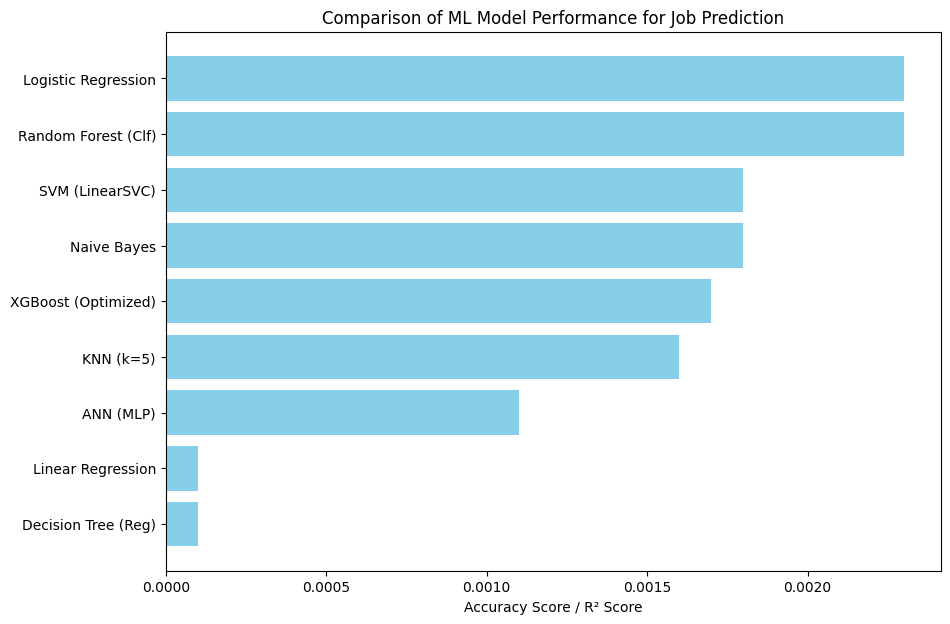

--- Performance Summary ---


,Model,Accuracy
0,Logistic Regression,0.0023
1,Random Forest (Clf),0.0023
3,SVM (LinearSVC),0.0018
5,Naive Bayes,0.0018
2,XGBoost (Optimized),0.0017
4,KNN (k=5),0.0016
6,ANN (MLP),0.0011
7,Linear Regression,0.0001
8,Decision Tree (Reg),0.0001



Conclusion: The best performing model is Logistic Regression, though performance remains low across all methods.


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from previous cell executions and new regression models
model_results = {
    'Logistic Regression': 0.0023,
    'Random Forest (Clf)': 0.0023,
    'XGBoost (Optimized)': 0.0017,
    'SVM (LinearSVC)': 0.0018,
    'KNN (k=5)': 0.0016,
    'Naive Bayes': 0.0018,
    'ANN (MLP)': 0.0011,
    'Linear Regression': 0.0001, # Based on R2 score from previous execution
    'Decision Tree (Reg)': 0.0001 # Based on R2 score from previous execution
}

comparison_df = pd.DataFrame(list(model_results.items()), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy Score / R² Score')
plt.title('Comparison of ML Model Performance for Job Prediction')
plt.gca().invert_yaxis()
plt.show()

print("--- Performance Summary ---")
display(comparison_df)

best_model = comparison_df.iloc[0]['Model']
print(f"\nConclusion: The best performing model is {best_model}, though performance remains low across all methods.")